# CICIDS2017 — Exploratory Data Analysis & Preprocessing
## Anomaly Detection in Network Traffic

This notebook covers:
1. Loading and merging all 8 daily CSV files
2. Data understanding — shape, types, missing values, class balance
3. Distribution analysis — per-feature histograms and box plots
4. Temporal analysis — traffic and attack patterns across the capture week
5. Correlation and redundancy analysis
6. Zero/sparse column analysis
7. Outlier analysis
8. Preprocessing — cleaning, encoding, scaling, export

---
## 0. Imports and Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
})
PALETTE_ATTACK = {'BENIGN': '#4C72B0', 'ATTACK': '#DD4444'}
PALETTE_DAY    = sns.color_palette('tab10', 8)

DATA_DIR = ''

---
## 1. Load and Merge

In [5]:
FILE_MAP = {
    'Monday-WorkingHours.pcap_ISCX.csv':                              'Monday',
    'Tuesday-WorkingHours.pcap_ISCX.csv':                             'Tuesday',
    'Wednesday-workingHours.pcap_ISCX.csv':                           'Wednesday',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv':         'Thursday-Morning',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv':    'Thursday-Afternoon',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv':                      'Friday-Morning',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv':           'Friday-PortScan',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv':               'Friday-DDoS',
}

frames = []
for filename, session_label in FILE_MAP.items():
    path = os.path.join(DATA_DIR, filename)
    df_tmp = pd.read_csv(path, low_memory=False)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp['capture_session'] = session_label
    frames.append(df_tmp)
    print(f'Loaded {session_label:30s} | rows: {len(df_tmp):>8,}  cols: {df_tmp.shape[1]}')

df = pd.concat(frames, ignore_index=True)
print(f'\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded Monday                         | rows:   13,842  cols: 80
Loaded Tuesday                        | rows:   15,333  cols: 80
Loaded Wednesday                      | rows:   15,181  cols: 80
Loaded Thursday-Morning               | rows:   17,085  cols: 80
Loaded Thursday-Afternoon             | rows:   16,943  cols: 80
Loaded Friday-Morning                 | rows:    3,384  cols: 80
Loaded Friday-PortScan                | rows:    3,416  cols: 80
Loaded Friday-DDoS                    | rows:    3,168  cols: 80

Merged dataset: 88,352 rows x 80 columns


---
## 2. Data Understanding

In [6]:
# Basic shape and types
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes.value_counts())
print('\nFirst 3 rows:')
df.head(3)

Shape: (88352, 80)

Data types:
float64    70
int64       8
object      2
Name: count, dtype: int64

First 3 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,capture_session
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Monday


In [8]:
# Descriptive statistics for numeric columns
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,88352.000000,8.835200e+04,88352.000000,88352.000000,8.835200e+04,8.835200e+04,88352.000000,88352.000000,88352.000000,88351.000000,...,88345.000000,8.834500e+04,8.834500e+04,8.834500e+04,8.834500e+04,8.834500e+04,8.834500e+04,8.834500e+04,8.834500e+04,8.834500e+04
mean,6164.451852,1.774663e+07,61.045941,77.636828,1.116074e+03,1.633257e+05,257.516898,19.814967,63.478316,78.513959,...,49.486751,-5.030027e+04,1.429114e+05,8.336223e+04,2.918592e+05,9.617186e+04,6.187222e+06,2.450996e+05,6.374869e+06,5.941164e+06
std,16058.240878,3.595762e+07,2982.509953,3963.918897,1.799777e+04,8.883422e+06,727.210888,44.180511,140.602330,203.926717,...,2742.739064,4.240648e+06,9.452187e+05,5.878215e+05,1.512554e+06,8.419768e+05,1.676147e+07,2.451822e+06,1.714583e+07,1.658824e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,2.630000e+02,2.000000,1.000000,3.700000e+01,6.000000e+00,30.000000,0.000000,14.333333,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,6.441450e+04,2.000000,2.000000,7.800000e+01,1.510000e+02,47.000000,6.000000,42.000000,0.000000,...,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,5.880219e+06,8.000000,6.000000,5.140000e+02,1.034000e+03,307.000000,41.000000,57.000000,89.224810,...,4.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,64628.000000,1.200000e+08,219759.000000,291922.000000,1.323378e+06,6.554530e+08,24820.000000,1472.000000,4640.757576,7125.596846,...,213557.000000,6.000000e+01,1.016597e+08,5.892773e+07,1.016597e+08,1.016597e+08,1.200000e+08,7.590000e+07,1.200000e+08,1.200000e+08


In [38]:
#columns list
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [9]:
# Missing values and inf values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

inf_counts  = np.isinf(df[numeric_cols]).sum()
nan_counts  = df.isnull().sum()

quality_df = pd.DataFrame({
    'missing':   nan_counts,
    'inf':        inf_counts.reindex(nan_counts.index, fill_value=0),
    'missing_%': (nan_counts / len(df) * 100).round(2),
}).sort_values('missing', ascending=False)

problematic = quality_df[(quality_df['missing'] > 0) | (quality_df['inf'] > 0)]
print(f'Columns with missing or inf values: {len(problematic)}')
problematic

Columns with missing or inf values: 70


,missing,inf,missing_%
Flow Bytes/s,21,80,0.02
Active Std,7,0,0.01
Idle Min,7,0,0.01
Label,7,0,0.01
Idle Std,7,0,0.01
...,...,...,...
Bwd Packet Length Std,1,0,0.00
Bwd Packet Length Min,1,0,0.00
Fwd Packet Length Std,1,0,0.00
Bwd Packet Length Max,1,0,0.00


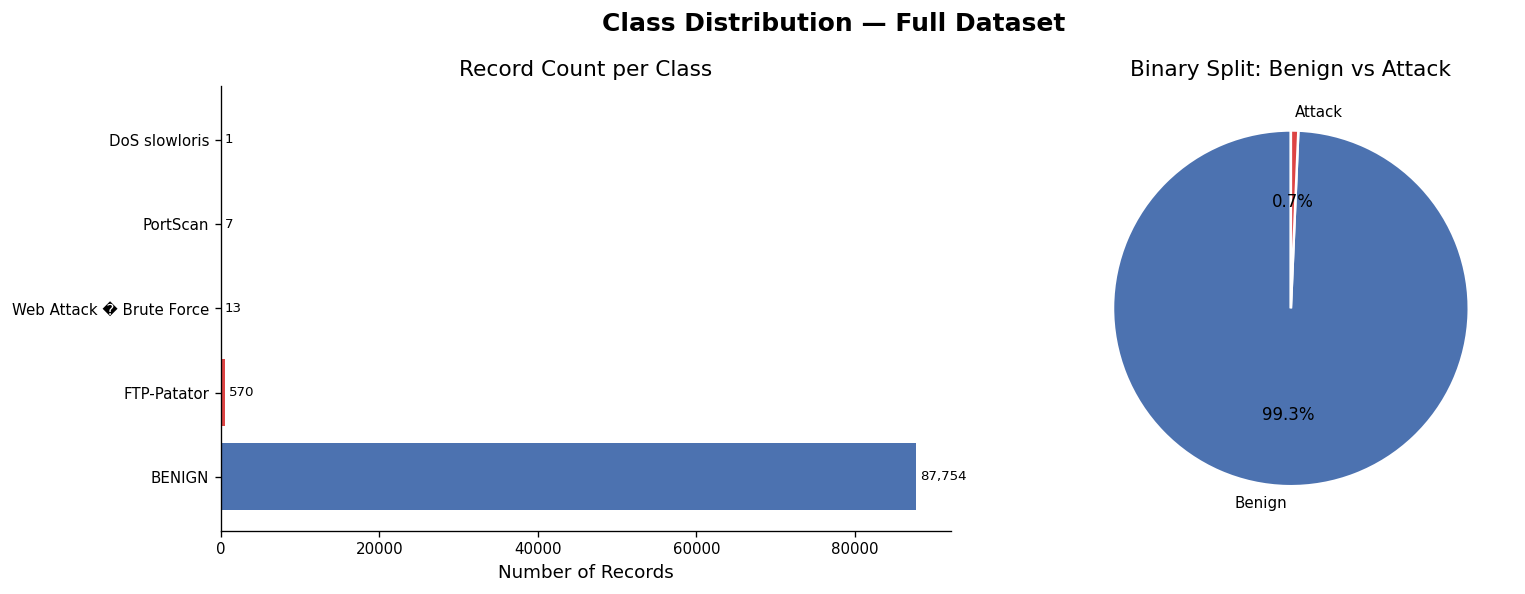

In [10]:
# Class distribution — raw label
label_col = ' Label' if ' Label' in df.columns else 'Label'
df[label_col] = df[label_col].str.strip()

label_counts = df[label_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Full Dataset', fontweight='bold')

# Bar chart
colors = ['#4C72B0' if v == 'BENIGN' else '#DD4444' for v in label_counts.index]
axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Number of Records')
axes[0].set_title('Record Count per Class')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=8)

# Pie chart
benign_total = label_counts.get('BENIGN', 0)
attack_total = label_counts.sum() - benign_total
axes[1].pie(
    [benign_total, attack_total],
    labels=['Benign', 'Attack'],
    colors=['#4C72B0', '#DD4444'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Binary Split: Benign vs Attack')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

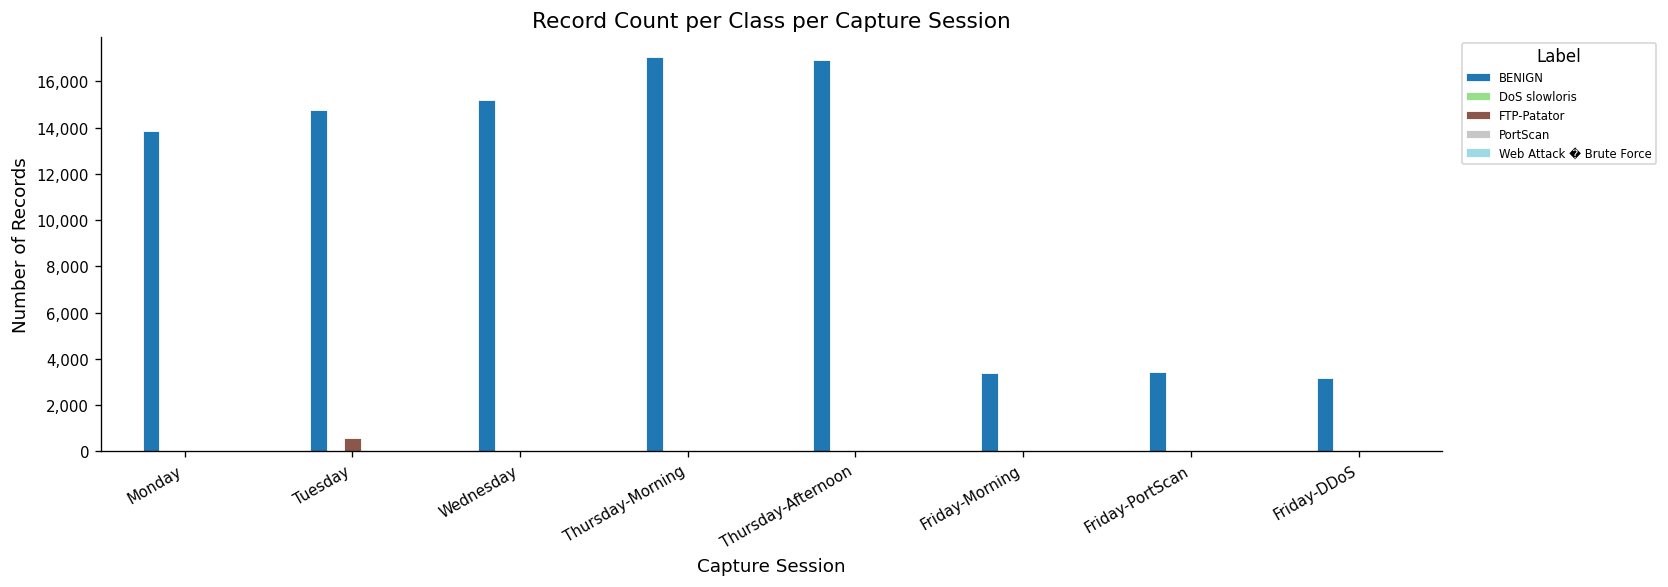

In [11]:
# Class distribution per capture session
session_label = df.groupby(['capture_session', label_col]).size().unstack(fill_value=0)

session_order = list(FILE_MAP.values())
session_label = session_label.reindex([s for s in session_order if s in session_label.index])

fig, ax = plt.subplots(figsize=(14, 5))
session_label.plot(kind='bar', ax=ax, colormap='tab20', edgecolor='white', linewidth=0.5)
ax.set_title('Record Count per Class per Capture Session')
ax.set_xlabel('Capture Session')
ax.set_ylabel('Number of Records')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('class_per_session.png', bbox_inches='tight')
plt.show()

---
## 3. Temporal Analysis

In [12]:
# Parse Timestamp if present
ts_col = None
for candidate in [' Timestamp', 'Timestamp', 'timestamp']:
    if candidate in df.columns:
        ts_col = candidate
        break

if ts_col:
    df['timestamp_parsed'] = pd.to_datetime(df[ts_col], infer_datetime_format=True, errors='coerce')
    df['hour']    = df['timestamp_parsed'].dt.hour
    df['day_name'] = df['timestamp_parsed'].dt.day_name()
    print('Timestamp parsed successfully.')
    print(df['timestamp_parsed'].describe())
else:
    print('No timestamp column found. Temporal plots will use capture_session instead.')

No timestamp column found. Temporal plots will use capture_session instead.


In [13]:
# Hourly traffic volume (if timestamp available)
if ts_col and 'hour' in df.columns:
    df_binary = df.copy()
    df_binary['is_attack'] = (df_binary[label_col] != 'BENIGN').astype(int)

    hourly = df_binary.groupby(['day_name', 'hour'])['is_attack'].agg(['sum', 'count'])
    hourly.columns = ['attacks', 'total']
    hourly['benign'] = hourly['total'] - hourly['attacks']
    hourly = hourly.reset_index()

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    days_present = [d for d in days_order if d in hourly['day_name'].unique()]

    fig, axes = plt.subplots(len(days_present), 1, figsize=(14, 4 * len(days_present)), sharex=True)
    fig.suptitle('Hourly Traffic Volume by Day — Benign vs Attack', fontweight='bold', y=1.01)

    for i, day in enumerate(days_present):
        d = hourly[hourly['day_name'] == day].sort_values('hour')
        axes[i].bar(d['hour'], d['benign'],  label='Benign', color='#4C72B0', alpha=0.85)
        axes[i].bar(d['hour'], d['attacks'], label='Attack', color='#DD4444', alpha=0.85,
                    bottom=d['benign'])
        axes[i].set_ylabel('Records')
        axes[i].set_title(day)
        axes[i].legend(loc='upper right')
        axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    axes[-1].set_xlabel('Hour of Day')
    plt.tight_layout()
    plt.savefig('hourly_traffic.png', bbox_inches='tight')
    plt.show()

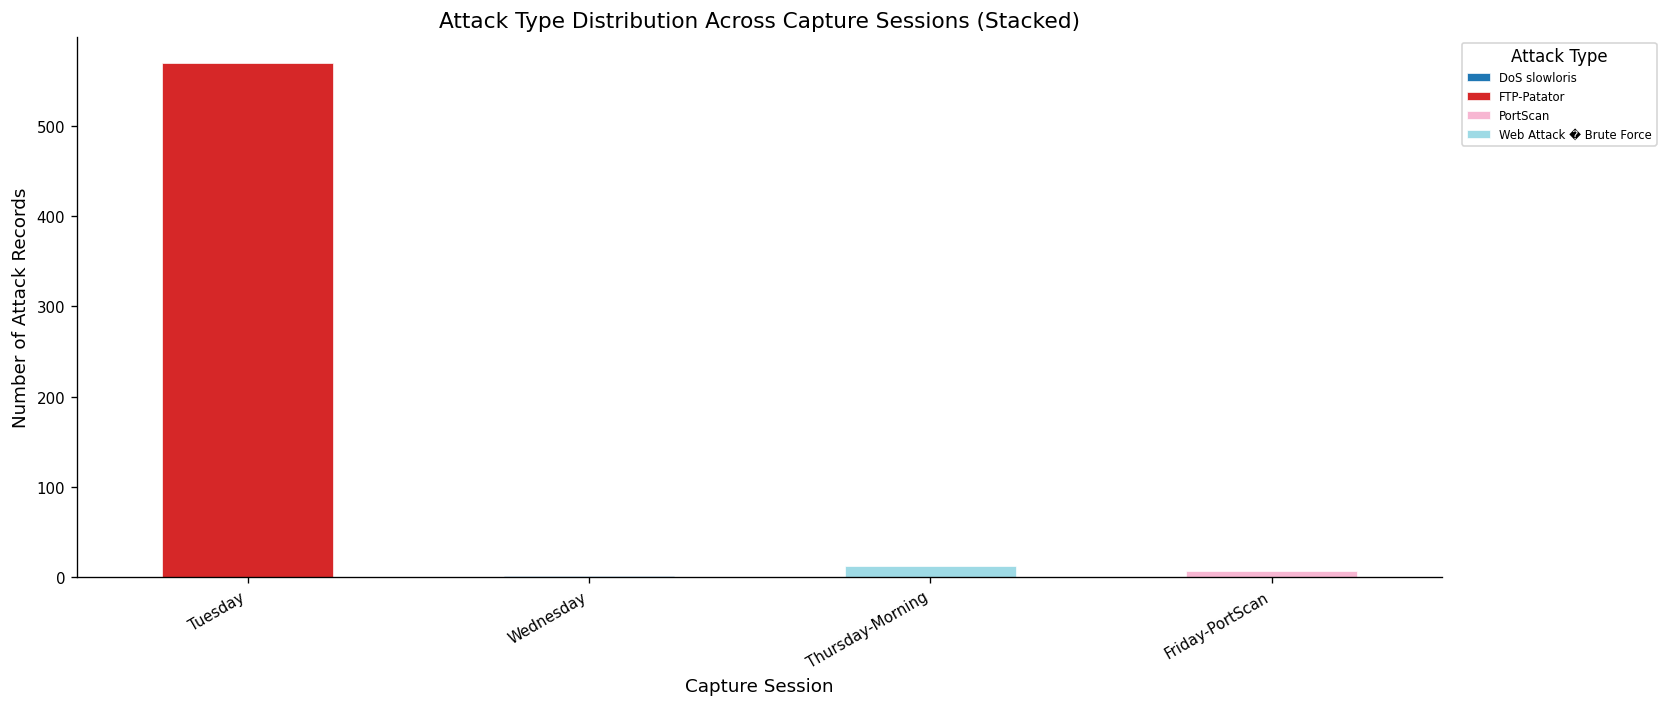

In [14]:
# Attack type timeline across sessions
attack_df = df[df[label_col] != 'BENIGN'].copy()
attack_timeline = attack_df.groupby(['capture_session', label_col]).size().unstack(fill_value=0)
attack_timeline = attack_timeline.reindex([s for s in session_order if s in attack_timeline.index])

fig, ax = plt.subplots(figsize=(14, 6))
attack_timeline.plot(kind='bar', stacked=True, ax=ax, colormap='tab20',
                     edgecolor='white', linewidth=0.4)
ax.set_title('Attack Type Distribution Across Capture Sessions (Stacked)')
ax.set_xlabel('Capture Session')
ax.set_ylabel('Number of Attack Records')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Attack Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('attack_timeline.png', bbox_inches='tight')
plt.show()

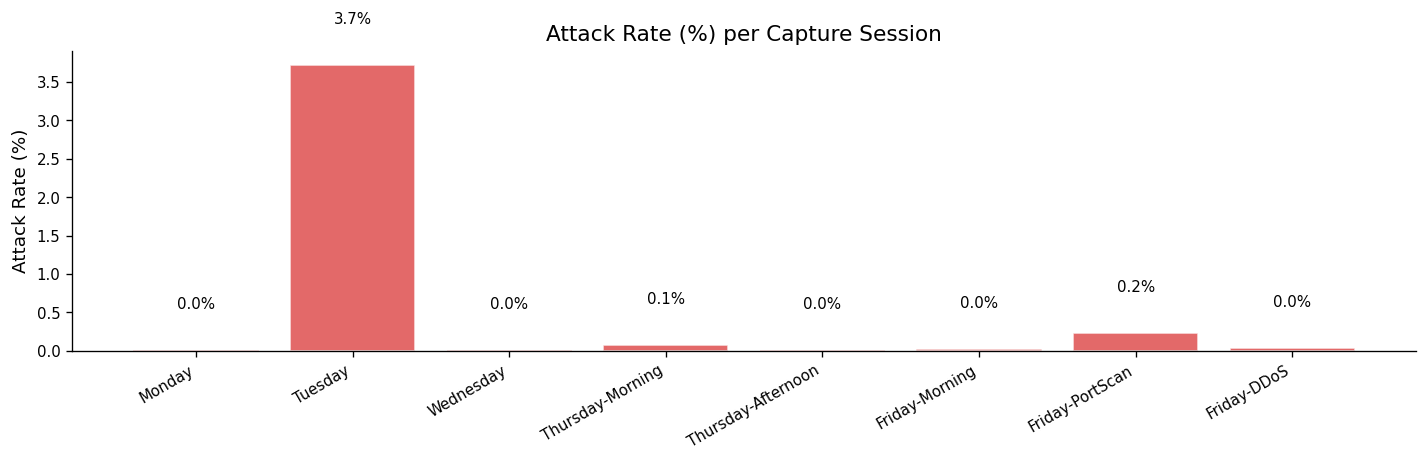

                      total  attacks  attack_rate_%
capture_session                                    
Monday              13842.0      1.0       0.007224
Tuesday             15333.0    570.0       3.717472
Wednesday           15181.0      2.0       0.013174
Thursday-Morning    17085.0     14.0       0.081943
Thursday-Afternoon  16943.0      1.0       0.005902
Friday-Morning       3384.0      1.0       0.029551
Friday-PortScan      3416.0      8.0       0.234192
Friday-DDoS          3168.0      1.0       0.031566


In [15]:
# Attack rate (%) per session — how aggressive is each session?
session_stats = df.groupby('capture_session').apply(
    lambda x: pd.Series({
        'total': len(x),
        'attacks': (x[label_col] != 'BENIGN').sum(),
        'attack_rate_%': (x[label_col] != 'BENIGN').mean() * 100
    })
).reindex([s for s in session_order if s in df['capture_session'].unique()])

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(session_stats.index, session_stats['attack_rate_%'],
              color='#DD4444', alpha=0.8, edgecolor='white')
ax.set_title('Attack Rate (%) per Capture Session')
ax.set_ylabel('Attack Rate (%)')
ax.set_xticklabels(session_stats.index, rotation=30, ha='right')
for bar, val in zip(bars, session_stats['attack_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('attack_rate_per_session.png', bbox_inches='tight')
plt.show()
print(session_stats)

---
## 4. Sparse / Zero-Heavy Column Analysis

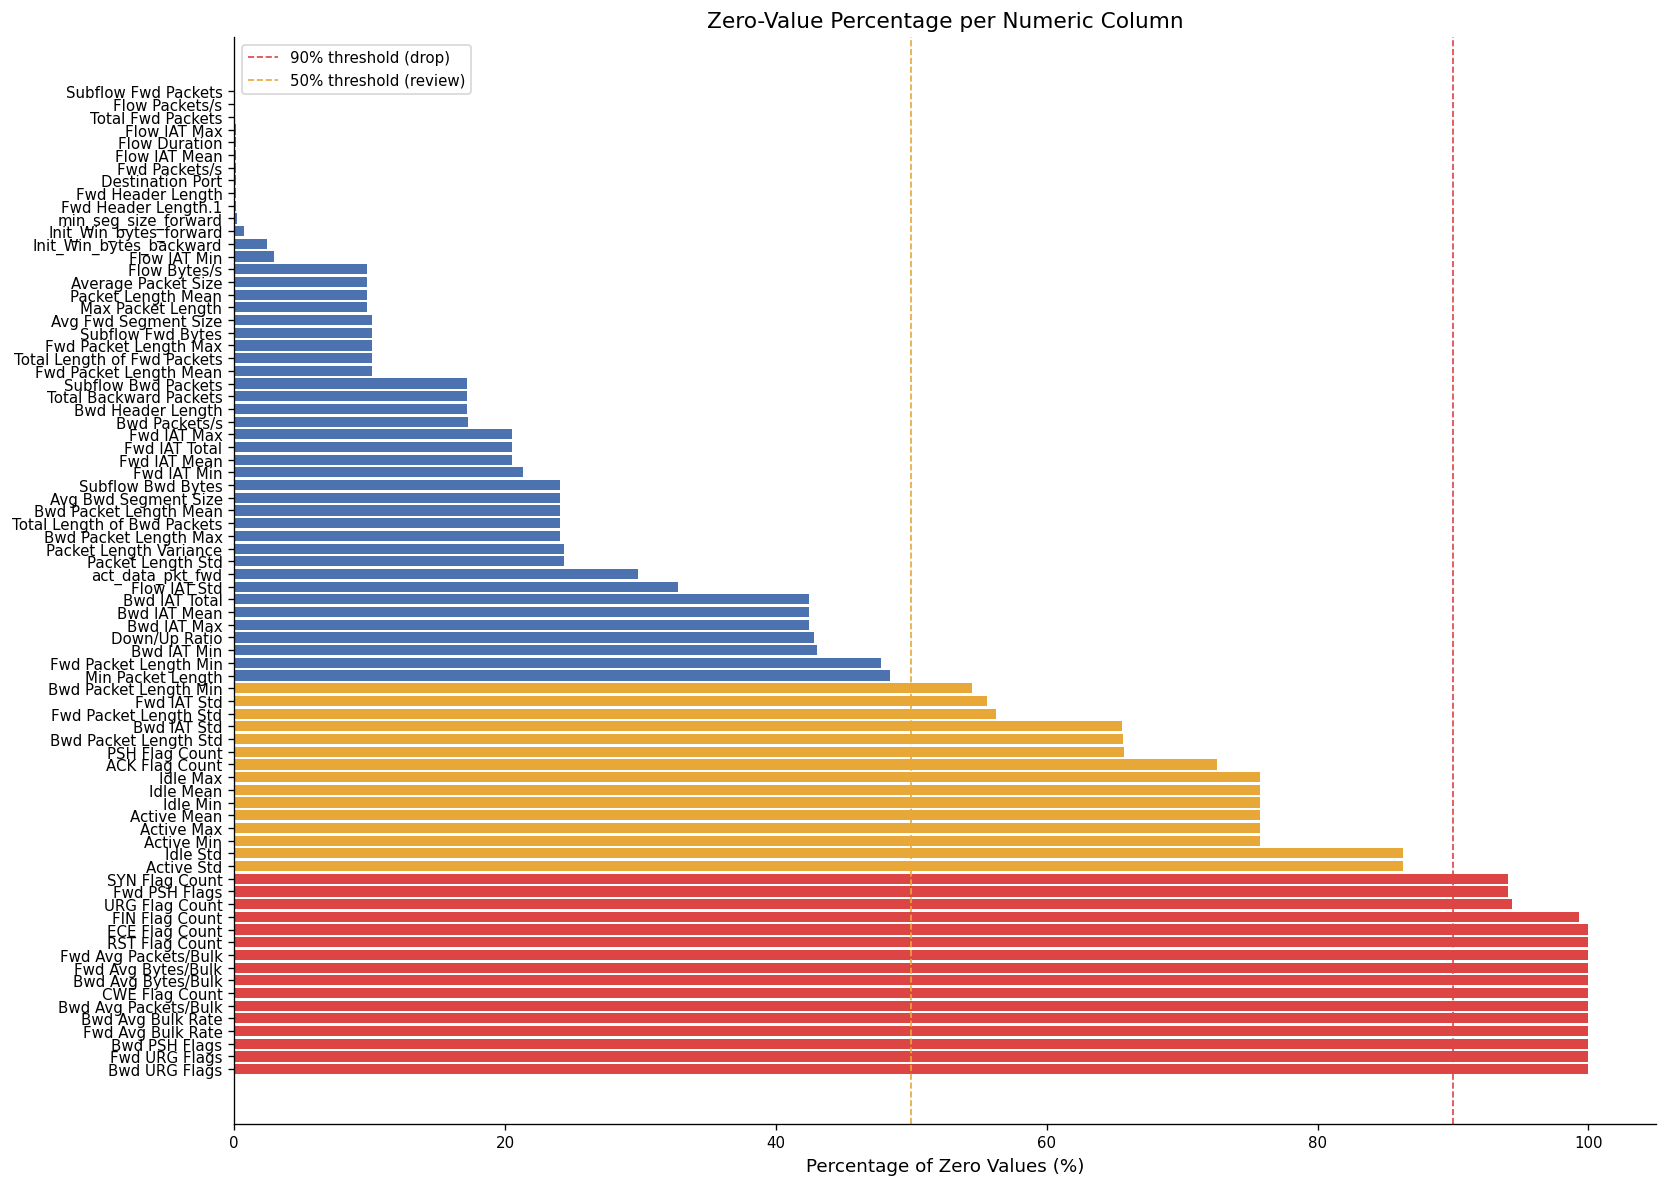

Columns that are 100% zero (to drop): 0
[]


In [16]:
# Zero percentage per numeric column
zero_pct = (df[numeric_cols] == 0).mean() * 100
zero_pct = zero_pct.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
colors_z = ['#DD4444' if v >= 90 else '#E8A838' if v >= 50 else '#4C72B0'
            for v in zero_pct.values]
ax.barh(zero_pct.index, zero_pct.values, color=colors_z)
ax.axvline(90, color='#DD4444', linestyle='--', linewidth=1, label='90% threshold (drop)')
ax.axvline(50, color='#E8A838', linestyle='--', linewidth=1, label='50% threshold (review)')
ax.set_xlabel('Percentage of Zero Values (%)')
ax.set_title('Zero-Value Percentage per Numeric Column')
ax.legend()
plt.tight_layout()
plt.savefig('zero_percentage.png', bbox_inches='tight')
plt.show()

cols_to_drop_zeros = zero_pct[zero_pct == 100].index.tolist()
print(f'Columns that are 100% zero (to drop): {len(cols_to_drop_zeros)}')
print(cols_to_drop_zeros)

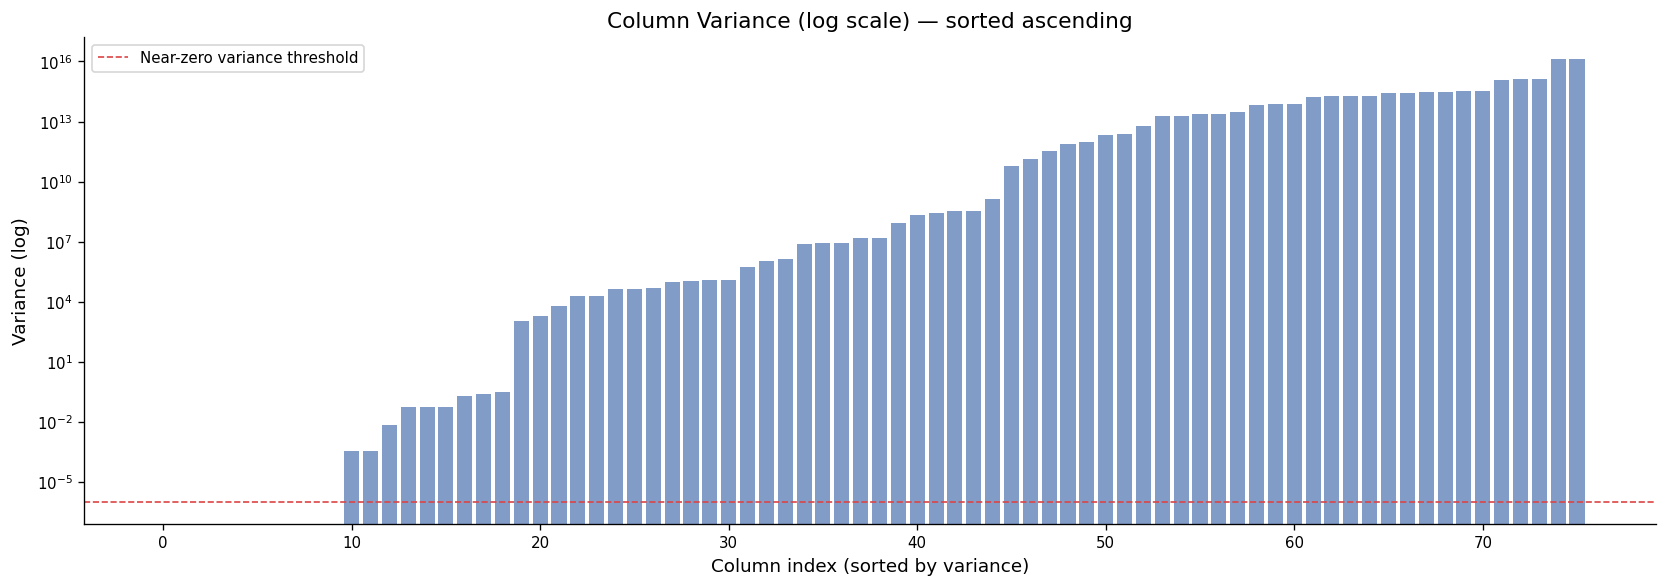

Near-zero variance columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate', 'Bwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk']


In [17]:
# Near-zero variance columns
variances = df[numeric_cols].var().sort_values()
low_var_cols = variances[variances < 1e-6].index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(variances)), variances.values, color='#4C72B0', alpha=0.7)
ax.axhline(1e-6, color='#DD4444', linestyle='--', linewidth=1, label='Near-zero variance threshold')
ax.set_yscale('log')
ax.set_title('Column Variance (log scale) — sorted ascending')
ax.set_xlabel('Column index (sorted by variance)')
ax.set_ylabel('Variance (log)')
ax.legend()
plt.tight_layout()
plt.savefig('variance_plot.png', bbox_inches='tight')
plt.show()
print(f'Near-zero variance columns: {low_var_cols}')

---
## 5. Feature Distribution Analysis

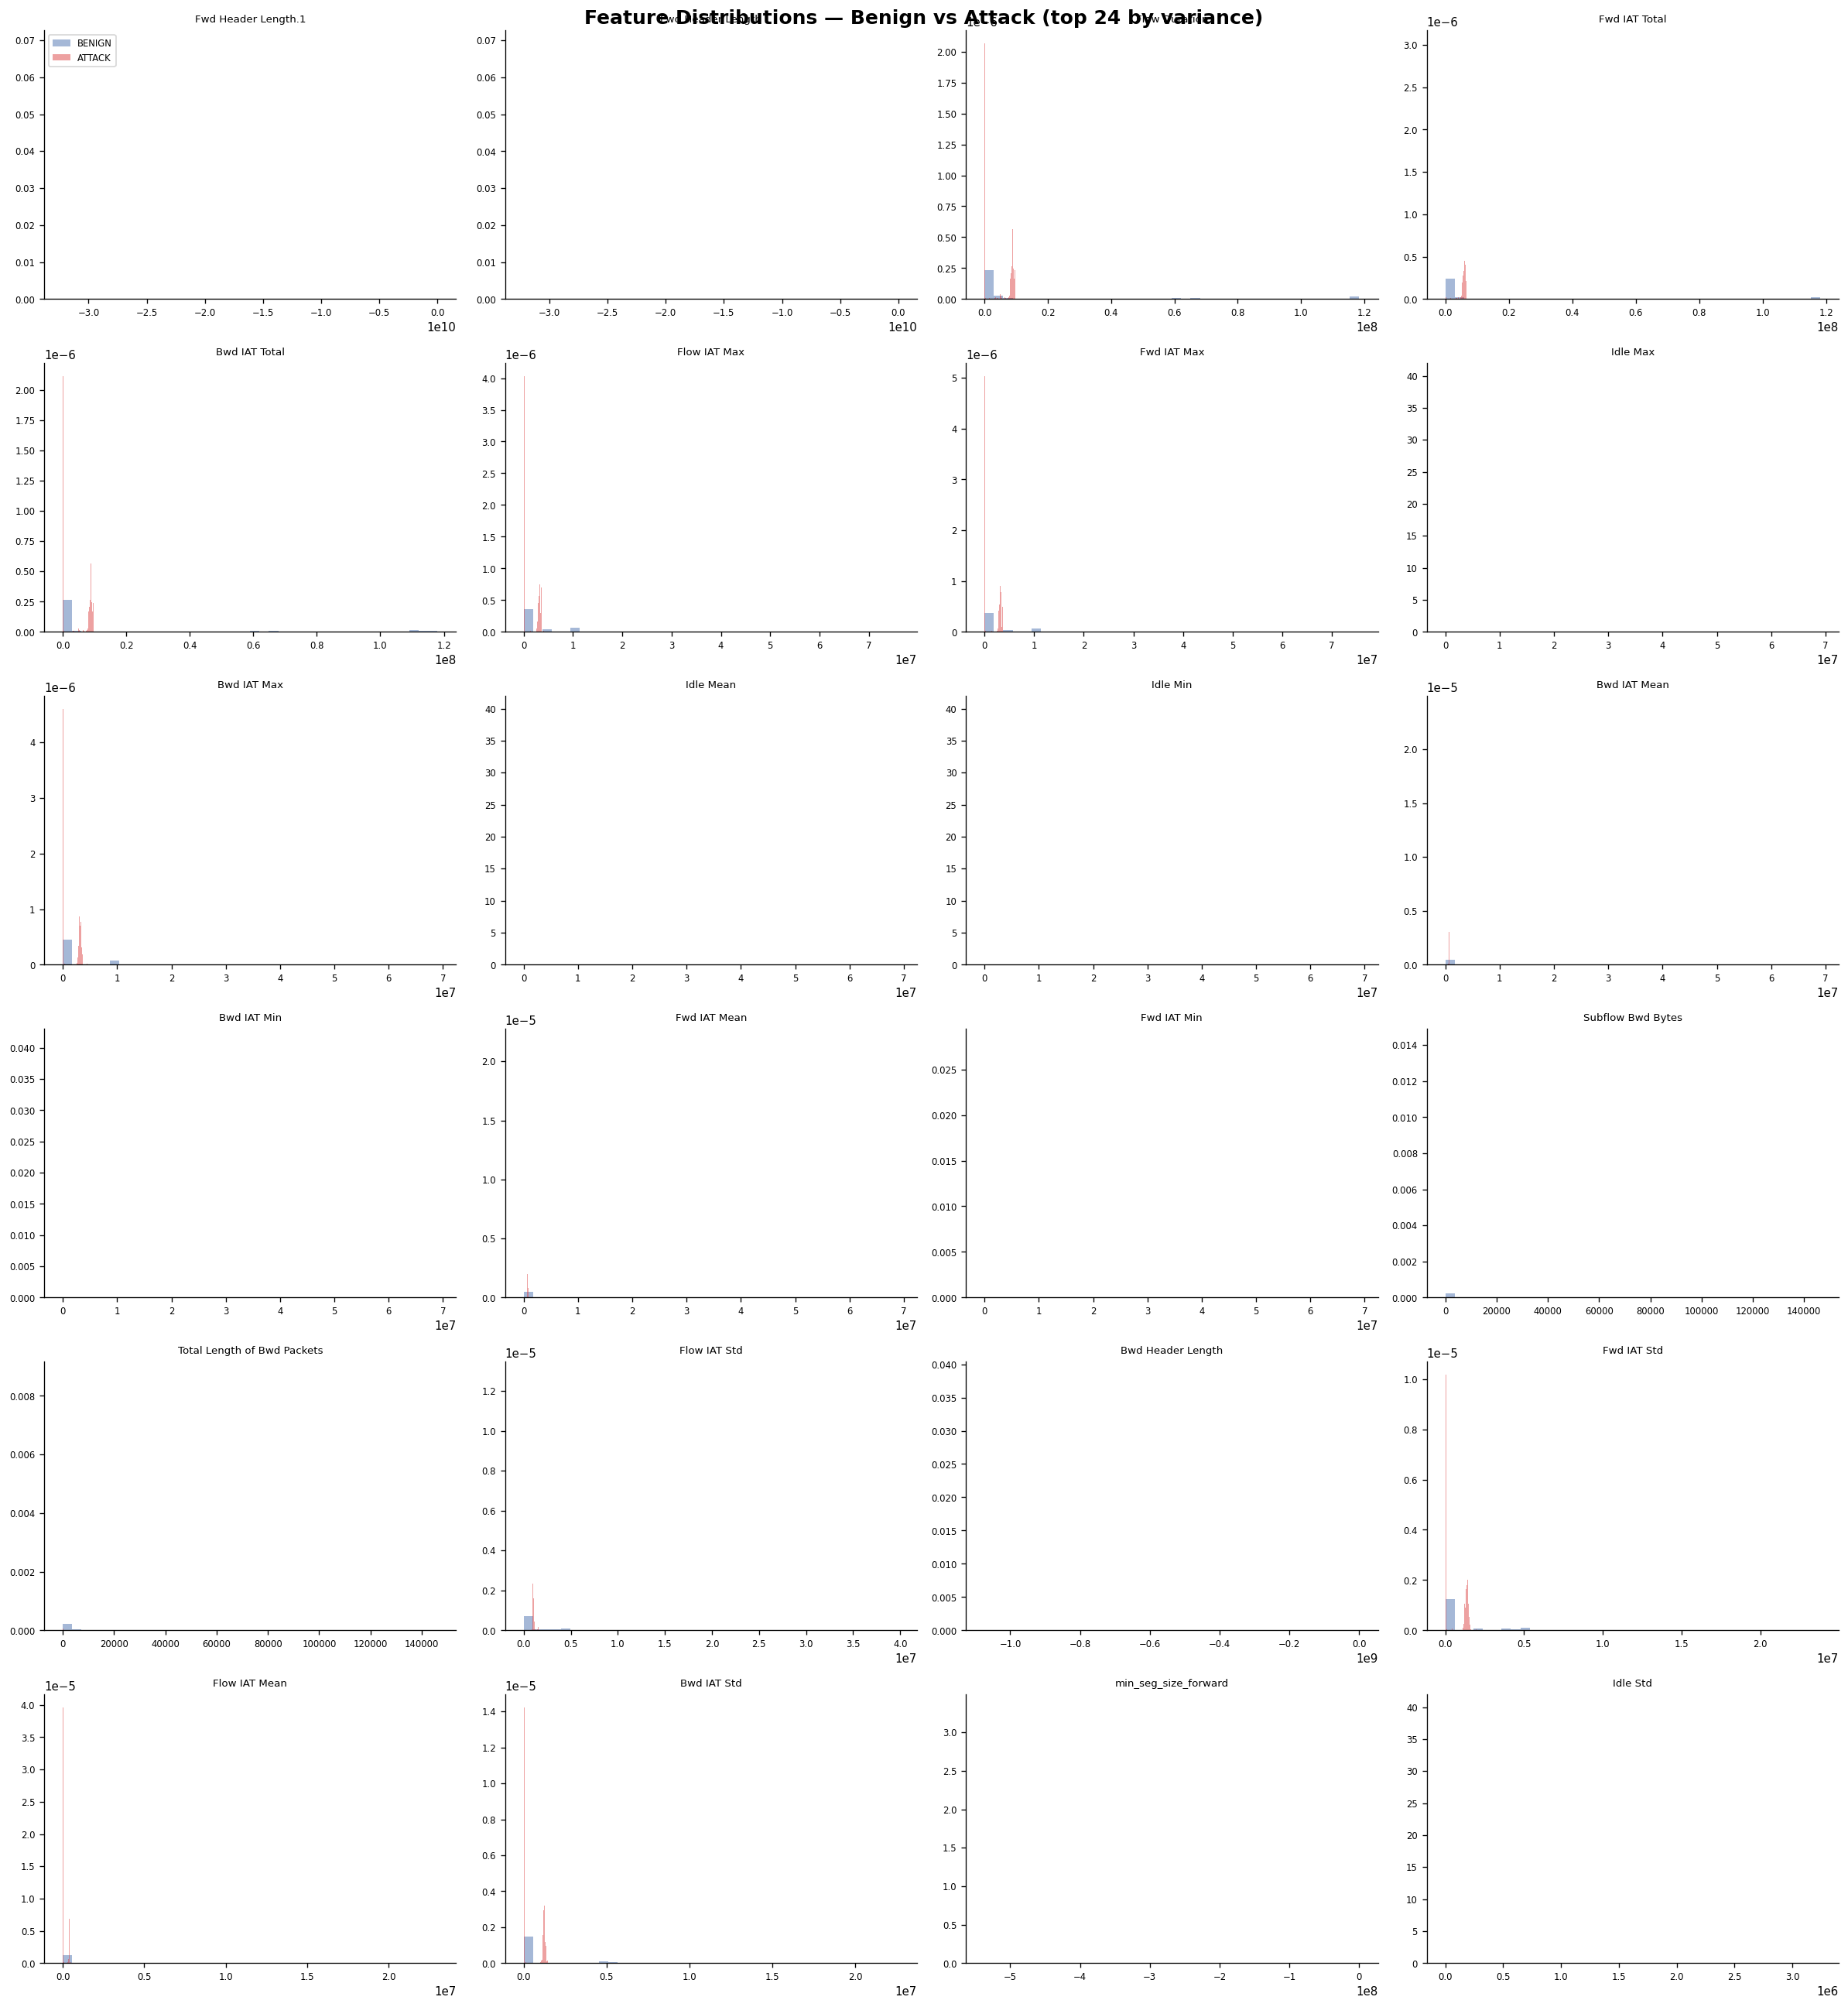

In [18]:
# Select a meaningful subset of features for distribution plots
# (exclude constant-zero and near-zero-variance columns)
cols_exclude = set(cols_to_drop_zeros + low_var_cols)
plot_features = [c for c in numeric_cols if c not in cols_exclude]

# Pick top 24 by variance for the overview grid
top24 = variances[plot_features].sort_values(ascending=False).head(24).index.tolist()

df['binary_label'] = df[label_col].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

fig, axes = plt.subplots(6, 4, figsize=(20, 22))
axes = axes.flatten()
fig.suptitle('Feature Distributions — Benign vs Attack (top 24 by variance)', fontweight='bold')

for i, col in enumerate(top24):
    ax = axes[i]
    for grp, color in [('BENIGN', '#4C72B0'), ('ATTACK', '#DD4444')]:
        data = df[df['binary_label'] == grp][col].replace([np.inf, -np.inf], np.nan).dropna()
        # Clip to 99th percentile for readability
        cap = data.quantile(0.99)
        data = data[data <= cap]
        ax.hist(data, bins=40, alpha=0.5, color=color, label=grp, density=True)
    ax.set_title(col[:35], fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

# Hide unused axes
for j in range(len(top24), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

In [19]:
# Box plots — key traffic features by attack type
key_features = [
    ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
    ' Total Length of Fwd Packets', ' Fwd Packet Length Mean',
    ' Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean'
]
# Keep only those that exist after stripping
key_features = [f for f in key_features if f in df.columns]

# Limit to top 10 attack classes by count + BENIGN
top_labels = label_counts.head(11).index.tolist()
df_box = df[df[label_col].isin(top_labels)].copy()

for feat in key_features:
    fig, ax = plt.subplots(figsize=(14, 4))
    clean = df_box[[label_col, feat]].replace([np.inf, -np.inf], np.nan).dropna()
    cap = clean[feat].quantile(0.97)
    clean = clean[clean[feat] <= cap]
    order = clean.groupby(label_col)[feat].median().sort_values(ascending=False).index
    sns.boxplot(data=clean, x=label_col, y=feat, order=order, ax=ax,
                palette='tab10', linewidth=0.8, fliersize=1)
    ax.set_title(f'Distribution of {feat.strip()} per Class (97th pct cap)')
    ax.set_xlabel('Traffic Class')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    safe_name = feat.strip().replace('/', '_').replace(' ', '_')
    plt.savefig(f'boxplot_{safe_name}.png', bbox_inches='tight')
    plt.show()

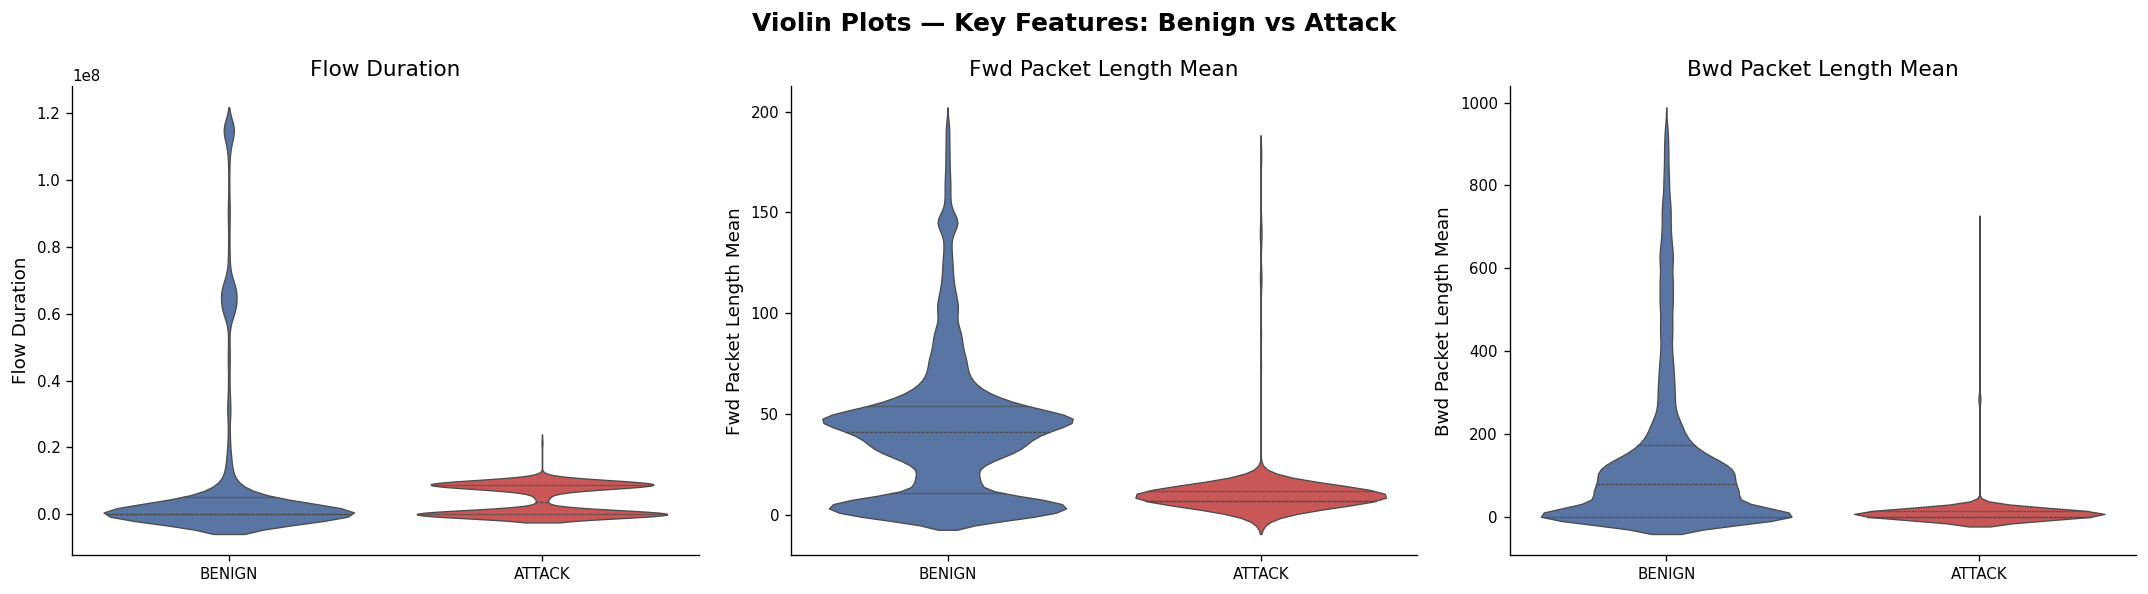

In [22]:
violin_features = [f for f in ['Flow Duration', 'Fwd Packet Length Mean',
                                'Bwd Packet Length Mean'] if f in df.columns]

fig, axes = plt.subplots(1, len(violin_features), figsize=(6 * len(violin_features), 5))
if len(violin_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, violin_features):
    # Ensure 'binary_label' is included for correct palette mapping
    clean = df_box[[label_col, 'binary_label', feat]].replace([np.inf, -np.inf], np.nan).dropna()
    cap = clean[feat].quantile(0.95)
    clean = clean[clean[feat] <= cap]
    sns.violinplot(data=clean, x='binary_label' if 'binary_label' in clean.columns else label_col,
                   y=feat, ax=ax, palette=PALETTE_ATTACK,
                   inner='quartile', linewidth=0.8)
    ax.set_title(feat.strip())
    ax.set_xlabel('')

fig.suptitle('Violin Plots — Key Features: Benign vs Attack', fontweight='bold')
plt.tight_layout()
plt.savefig('violin_plots.png', bbox_inches='tight')
plt.show()

---
## 6. Correlation Analysis

Too many features (68) for a readable heatmap. Showing top-50 by variance.


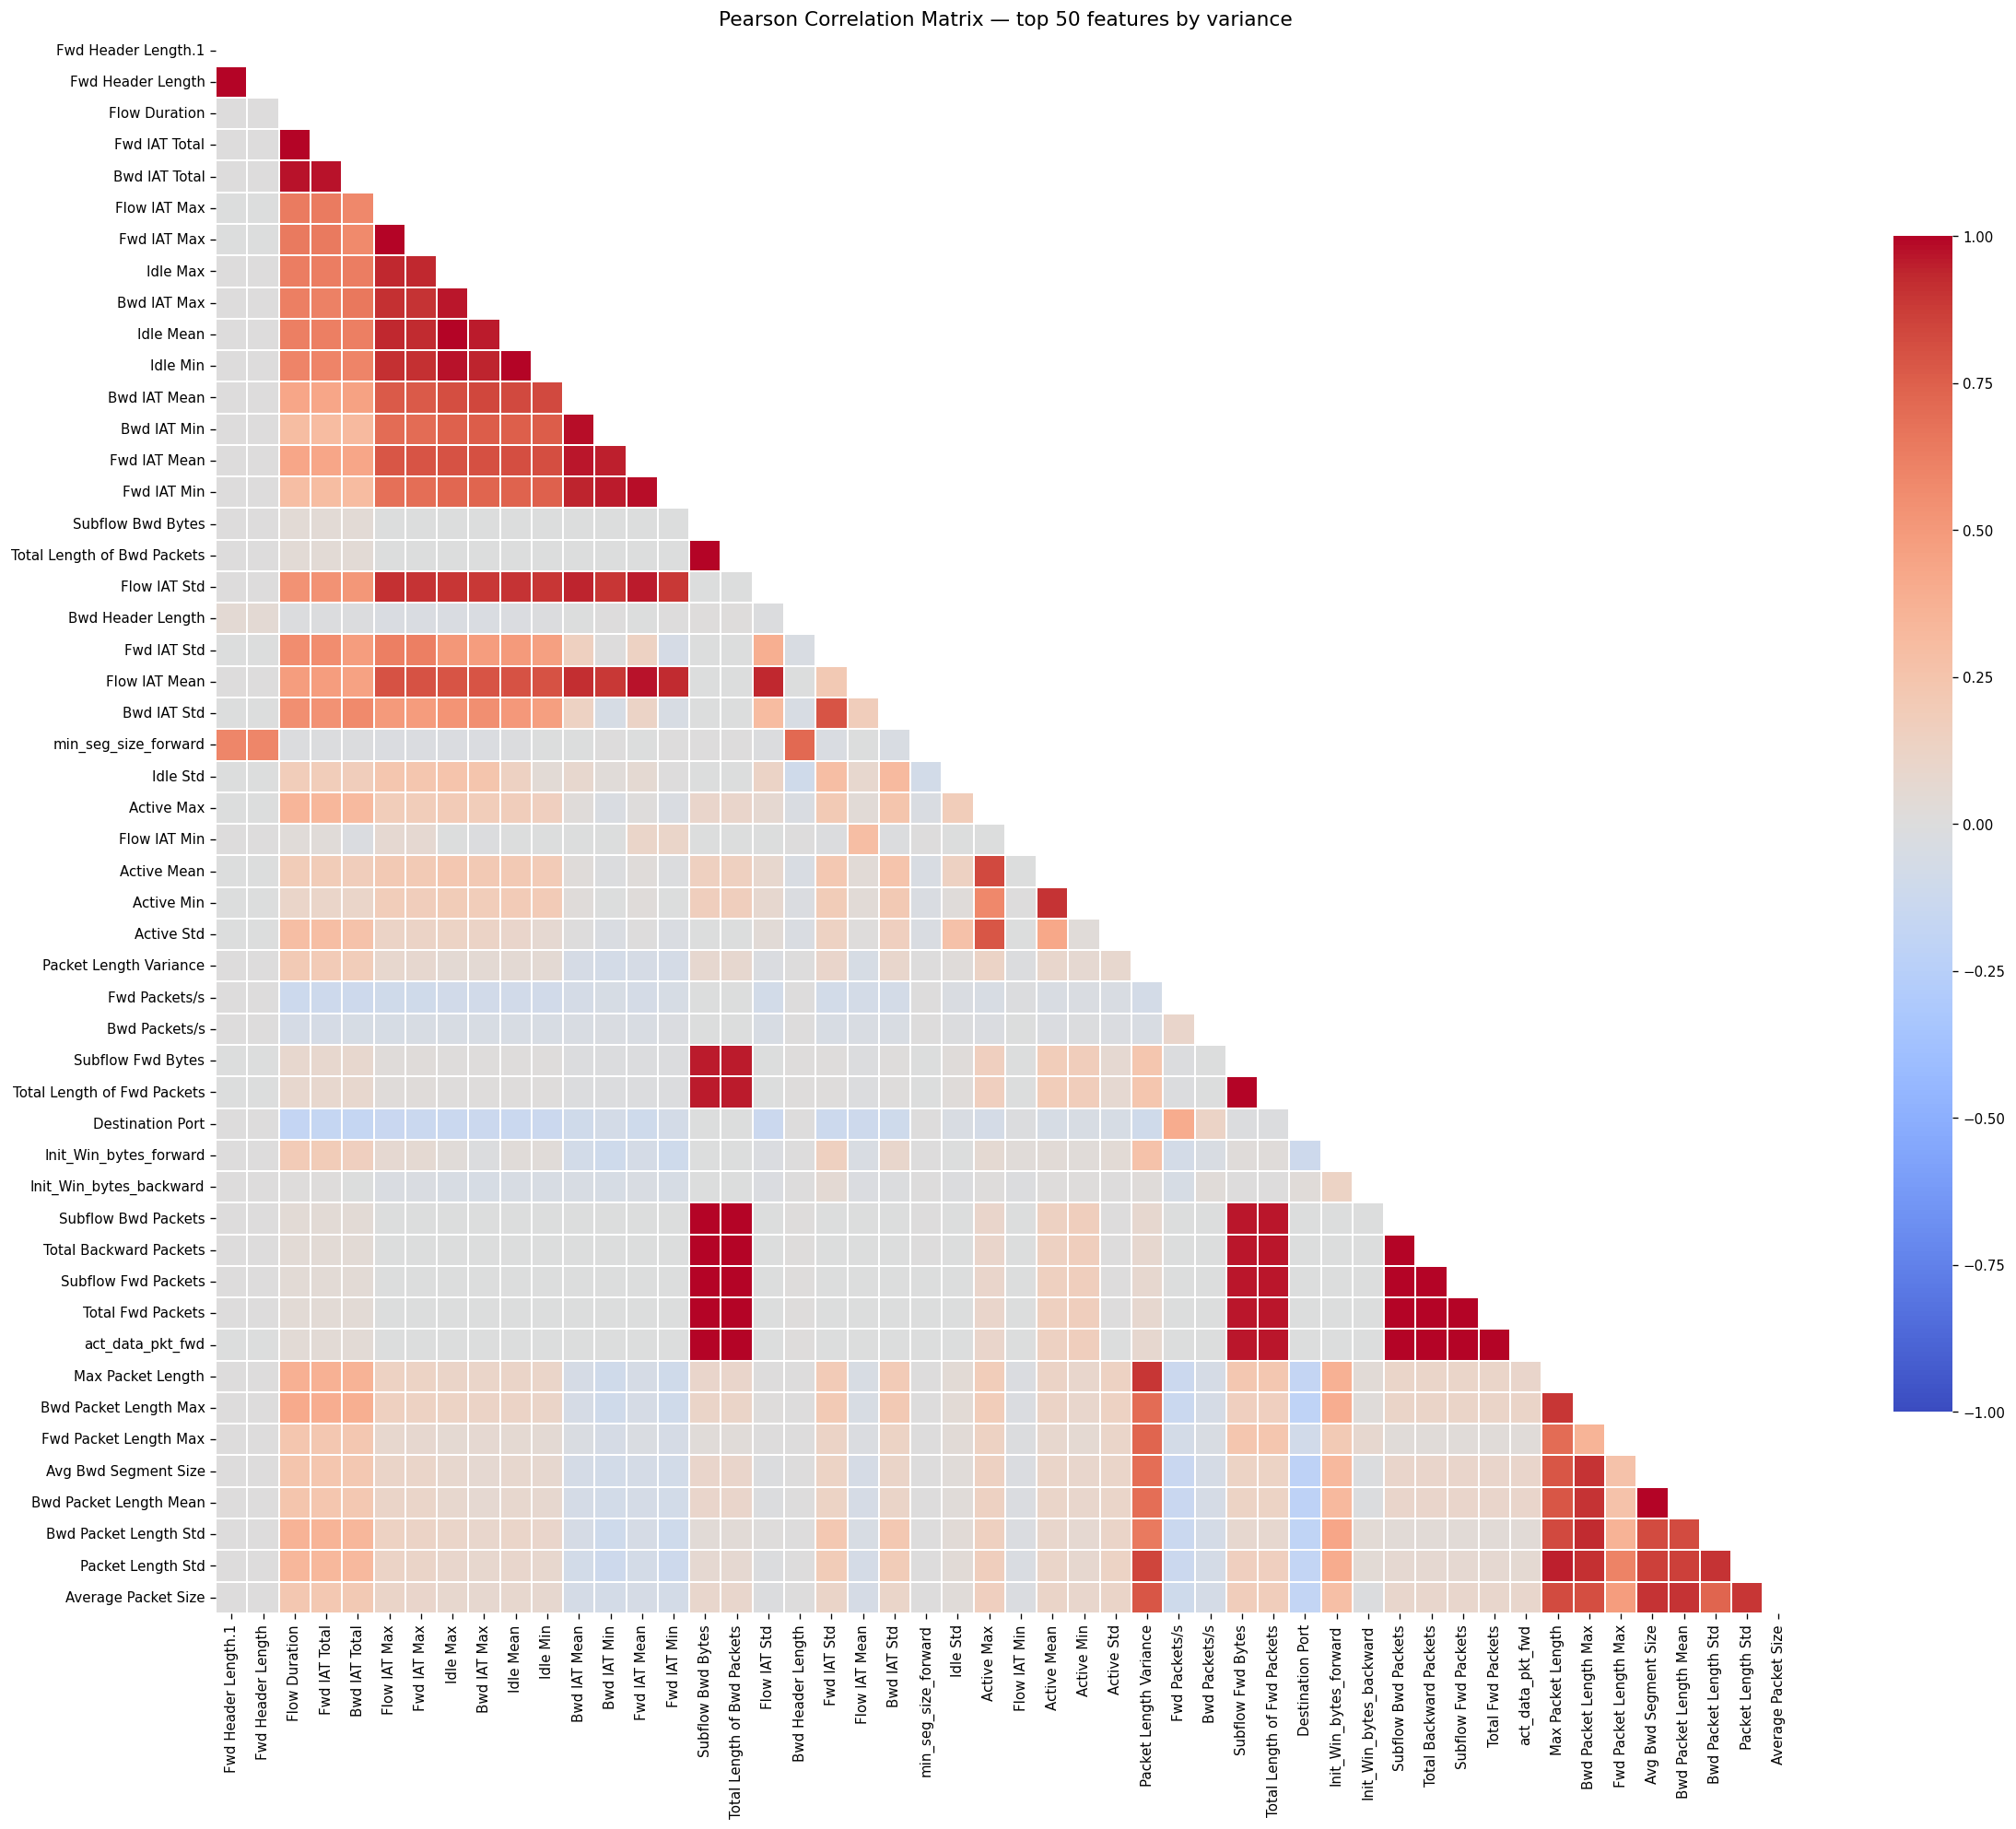

In [23]:
# Correlation heatmap on clean feature subset
df_clean_num = df[plot_features].replace([np.inf, -np.inf], np.nan)
# Sample for speed if dataset is very large
sample_size = min(50000, len(df_clean_num))
df_sample = df_clean_num.sample(sample_size, random_state=42)

corr_matrix = df_sample.corr()

# Plot only if manageable number of features
if len(plot_features) <= 50:
    fig, ax = plt.subplots(figsize=(18, 15))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.3,
                annot=False, square=True, cbar_kws={'shrink': 0.7})
    ax.set_title('Pearson Correlation Matrix (lower triangle)')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print(f'Too many features ({len(plot_features)}) for a readable heatmap. Showing top-50 by variance.')
    top50 = variances[plot_features].sort_values(ascending=False).head(50).index
    corr50 = df_sample[top50].corr()
    fig, ax = plt.subplots(figsize=(20, 17))
    mask = np.triu(np.ones_like(corr50, dtype=bool))
    sns.heatmap(corr50, mask=mask, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.2,
                annot=False, square=True, cbar_kws={'shrink': 0.7})
    ax.set_title('Pearson Correlation Matrix — top 50 features by variance')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', bbox_inches='tight')
    plt.show()

In [24]:
# Identify highly correlated pairs (|r| > 0.95)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if abs(upper_tri.loc[row, col]) > 0.95
]
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature A', 'Feature B', 'Correlation'])
high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False)

cols_to_drop_corr = high_corr_df.groupby('Feature A')['Feature B'].first().tolist()
print(f'Highly correlated pairs (|r| > 0.95): {len(high_corr_df)}')
print(f'Columns to drop (redundant): {len(cols_to_drop_corr)}')
high_corr_df.head(20)

Highly correlated pairs (|r| > 0.95): 58
Columns to drop (redundant): 25


,Feature A,Feature B,Correlation
23,Subflow Fwd Packets,Total Fwd Packets,1.000000
17,SYN Flag Count,Fwd PSH Flags,1.000000
18,ECE Flag Count,RST Flag Count,1.000000
20,Avg Fwd Segment Size,Fwd Packet Length Mean,1.000000
22,Fwd Header Length.1,Fwd Header Length,1.000000
33,Subflow Bwd Packets,Total Backward Packets,1.000000
21,Avg Bwd Segment Size,Bwd Packet Length Mean,1.000000
29,Subflow Fwd Bytes,Total Length of Fwd Packets,1.000000
41,Subflow Bwd Bytes,Total Length of Bwd Packets,1.000000
32,Subflow Bwd Packets,Total Fwd Packets,0.999685


---
## 7. Outlier Analysis

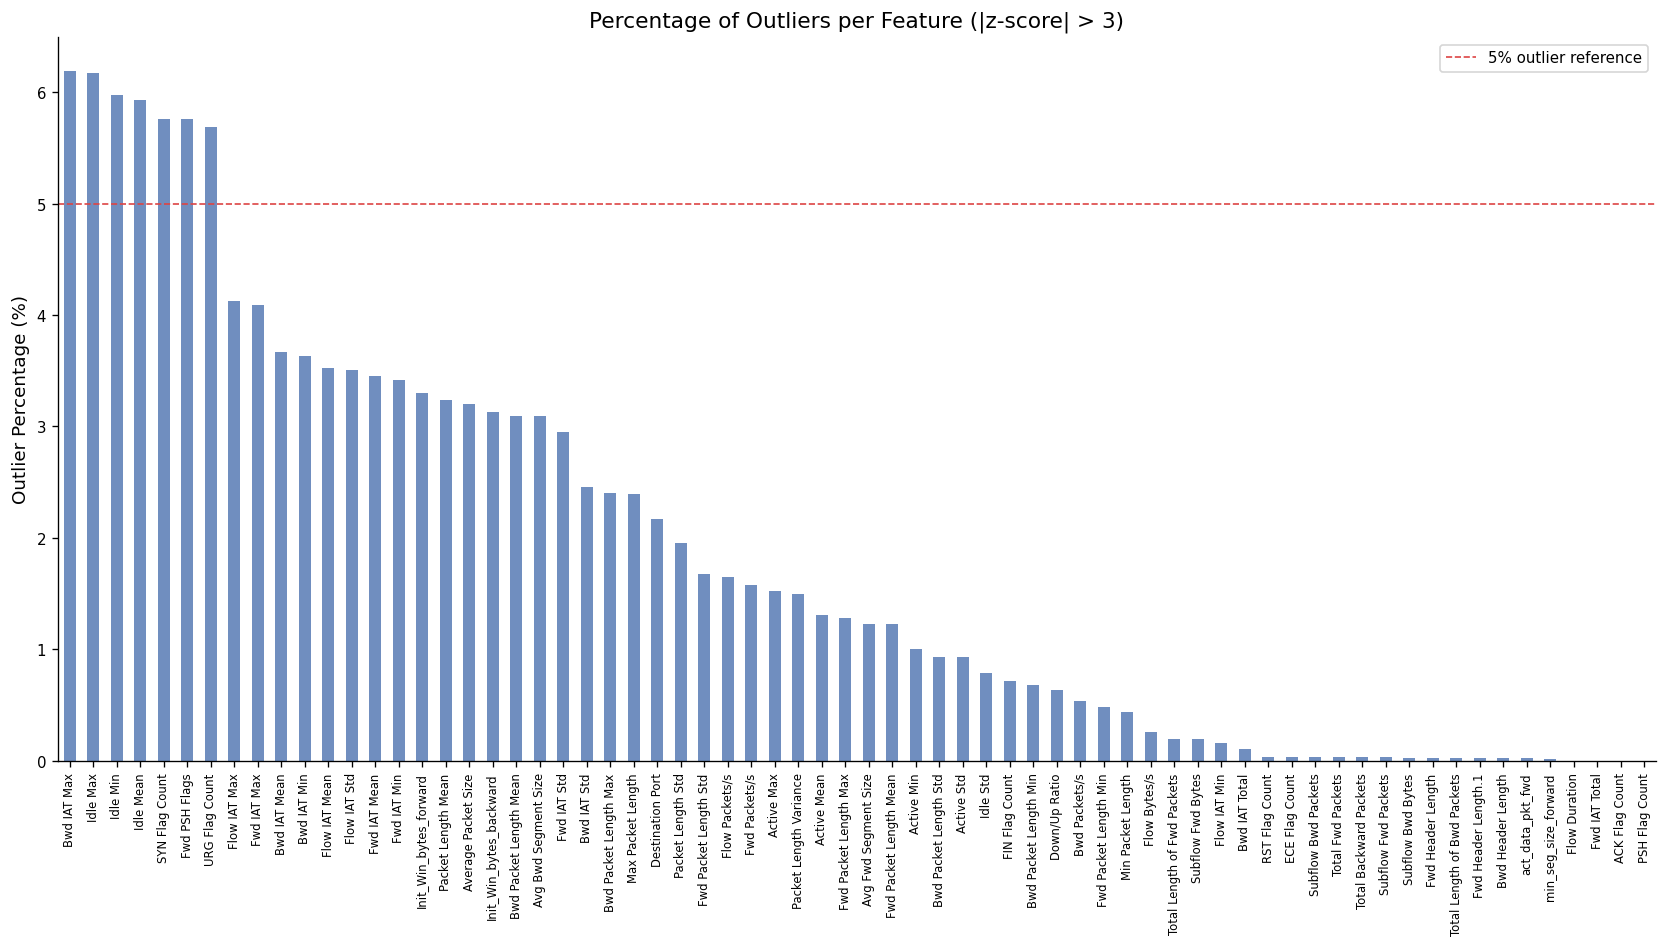

In [25]:
# Z-score based outlier detection per feature
df_for_outlier = df[plot_features].replace([np.inf, -np.inf], np.nan).dropna()
sample_out = df_for_outlier.sample(min(30000, len(df_for_outlier)), random_state=42)

z_scores = np.abs(stats.zscore(sample_out, nan_policy='omit'))
outlier_pct = (z_scores > 3).mean(axis=0) * 100
outlier_series = pd.Series(outlier_pct, index=sample_out.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
outlier_series.plot(kind='bar', ax=ax, color='#4C72B0', alpha=0.8)
ax.axhline(5, color='#DD4444', linestyle='--', linewidth=1, label='5% outlier reference')
ax.set_title('Percentage of Outliers per Feature (|z-score| > 3)')
ax.set_ylabel('Outlier Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.legend()
plt.tight_layout()
plt.savefig('outlier_analysis.png', bbox_inches='tight')
plt.show()

In [26]:
# Flow Bytes/s vs Flow Duration scatter — colored by binary label
feat_x = ' Flow Bytes/s'
feat_y = ' Flow Duration'

if feat_x in df.columns and feat_y in df.columns:
    scatter_df = df[[feat_x, feat_y, 'binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
    scatter_df = scatter_df[
        (scatter_df[feat_x] <= scatter_df[feat_x].quantile(0.98)) &
        (scatter_df[feat_y] <= scatter_df[feat_y].quantile(0.98))
    ].sample(min(20000, len(scatter_df)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, 6))
    for grp, color in [('BENIGN', '#4C72B0'), ('ATTACK', '#DD4444')]:
        sub = scatter_df[scatter_df['binary_label'] == grp]
        ax.scatter(sub[feat_x], sub[feat_y], c=color, label=grp,
                   alpha=0.3, s=4, rasterized=True)
    ax.set_xlabel(feat_x.strip())
    ax.set_ylabel(feat_y.strip())
    ax.set_title('Flow Bytes/s vs Flow Duration — Benign vs Attack')
    ax.legend(markerscale=4)
    plt.tight_layout()
    plt.savefig('scatter_bytes_duration.png', bbox_inches='tight')
    plt.show()

In [27]:
# Fwd vs Bwd packet counts scatter — colored by attack type
feat_x2 = ' Total Fwd Packets'
feat_y2 = ' Total Backward Packets'

if feat_x2 in df.columns and feat_y2 in df.columns:
    scatter2 = df[df[label_col].isin(top_labels)][[feat_x2, feat_y2, label_col]]\
        .replace([np.inf, -np.inf], np.nan).dropna()
    scatter2 = scatter2[
        (scatter2[feat_x2] <= scatter2[feat_x2].quantile(0.97)) &
        (scatter2[feat_y2] <= scatter2[feat_y2].quantile(0.97))
    ].sample(min(20000, len(scatter2)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, 7))
    palette = sns.color_palette('tab10', len(top_labels))
    for j, lbl in enumerate(top_labels):
        sub = scatter2[scatter2[label_col] == lbl]
        ax.scatter(sub[feat_x2], sub[feat_y2], c=[palette[j]], label=lbl,
                   alpha=0.35, s=5, rasterized=True)
    ax.set_xlabel(feat_x2.strip())
    ax.set_ylabel(feat_y2.strip())
    ax.set_title('Forward vs Backward Packet Count by Traffic Class')
    ax.legend(markerscale=4, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('scatter_fwd_bwd.png', bbox_inches='tight')
    plt.show()

---
## 8. PCA Visualization (2D)

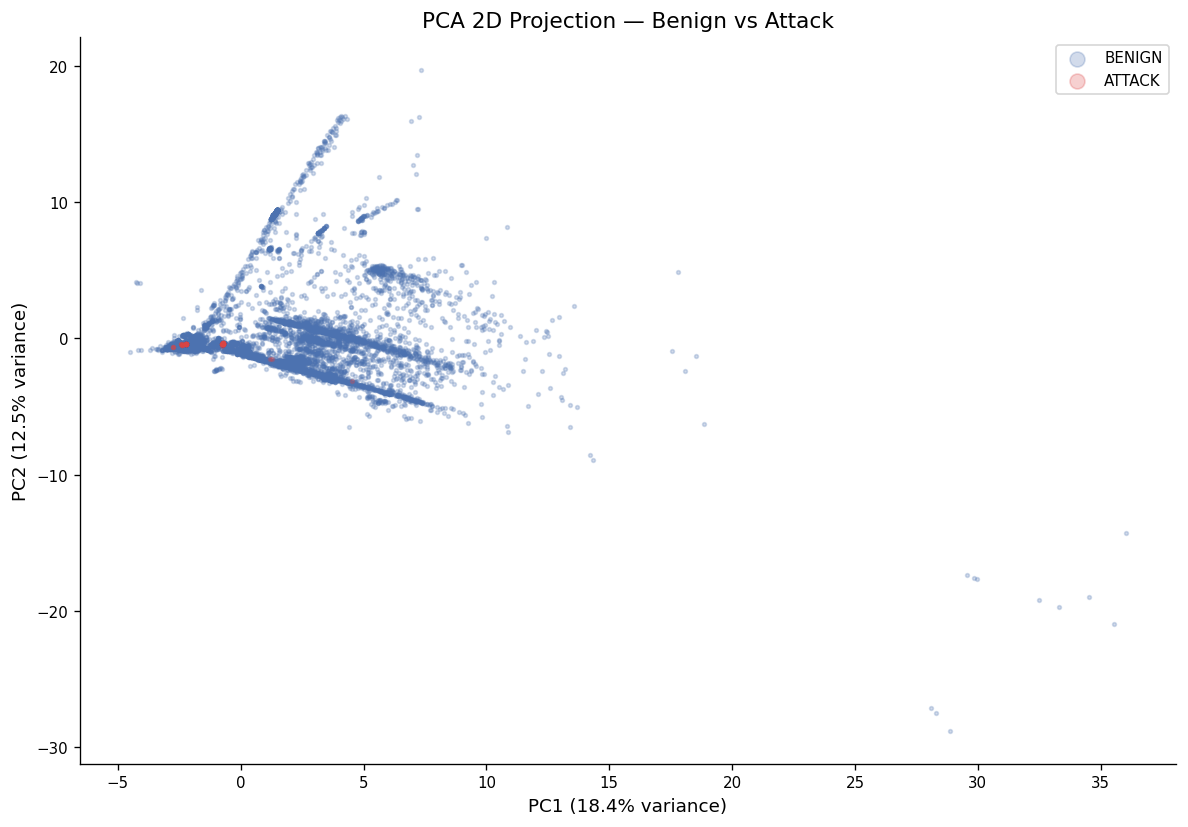

Total variance explained by 2 PCs: 30.9%


In [28]:
# PCA 2D projection to see separability
pca_features = [c for c in plot_features
                if c not in cols_to_drop_corr and c not in cols_to_drop_zeros]

df_pca_raw = df[pca_features + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
df_pca_sample = df_pca_raw.sample(min(15000, len(df_pca_raw)), random_state=42)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df_pca_sample[pca_features])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for grp, color in [('BENIGN', '#4C72B0'), ('ATTACK', '#DD4444')]:
    idx = df_pca_sample['binary_label'].values == grp
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=grp,
               alpha=0.25, s=5, rasterized=True)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA 2D Projection — Benign vs Attack')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('pca_2d.png', bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

---
## 9. Preprocessing — Clean, Encode, Scale, Export

In [29]:
# Step 1: Drop constant-zero and near-zero-variance columns
cols_to_remove = set(cols_to_drop_zeros + low_var_cols)
df_clean = df.drop(columns=[c for c in cols_to_remove if c in df.columns])
print(f'After removing zero/low-variance cols: {df_clean.shape}')

After removing zero/low-variance cols: (88352, 71)


In [30]:
# Step 2: Replace inf, drop NaN
num_cols_clean = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols_clean] = df_clean[num_cols_clean].replace([np.inf, -np.inf], np.nan)
before = len(df_clean)
df_clean = df_clean.dropna(subset=num_cols_clean)
print(f'Dropped {before - len(df_clean):,} rows with NaN/inf. Remaining: {len(df_clean):,}')

Dropped 107 rows with NaN/inf. Remaining: 88,245


In [31]:
# Step 3: Drop duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Dropped {before - len(df_clean):,} duplicate rows. Remaining: {len(df_clean):,}')

Dropped 1,152 duplicate rows. Remaining: 87,093


In [32]:
# Step 4: Drop highly correlated columns
df_clean = df_clean.drop(columns=[c for c in cols_to_drop_corr if c in df_clean.columns])
print(f'After dropping correlated cols: {df_clean.shape}')

After dropping correlated cols: (87093, 53)


In [33]:
'''
# Step 5: Remove DWH-bound identifier columns (go to dimensions)
id_cols = [' Source IP', ' Destination IP', ' Source Port',
           ' Destination Port', ' Protocol', ' Timestamp',
           'Flow ID', ' Flow ID', 'timestamp_parsed',
           'hour', 'day_name', 'capture_session']
df_clean = df_clean.drop(columns=[c for c in id_cols if c in df_clean.columns])
print(f'After removing identifier cols: {df_clean.shape}')
'''

"\n# Step 5: Remove DWH-bound identifier columns (go to dimensions)\nid_cols = [' Source IP', ' Destination IP', ' Source Port',\n           ' Destination Port', ' Protocol', ' Timestamp',\n           'Flow ID', ' Flow ID', 'timestamp_parsed',\n           'hour', 'day_name', 'capture_session']\ndf_clean = df_clean.drop(columns=[c for c in id_cols if c in df_clean.columns])\nprint(f'After removing identifier cols: {df_clean.shape}')\n"

In [34]:
# Step 6: Encode labels
label_col_clean = label_col if label_col in df_clean.columns else ' Label'
df_clean['label_multiclass'] = df_clean[label_col_clean].str.strip()
df_clean['label_binary']     = (df_clean['label_multiclass'] != 'BENIGN').astype(int)

# Build label encoding map
unique_labels = df_clean['label_multiclass'].unique()
label_map = {v: i for i, v in enumerate(sorted(unique_labels))}
df_clean['label_encoded'] = df_clean['label_multiclass'].map(label_map)

print('Label encoding map:')
for k, v in label_map.items():
    print(f'  {v}: {k}')

Label encoding map:
  0: BENIGN
  1: DoS slowloris
  2: FTP-Patator
  3: PortScan
  4: Web Attack � Brute Force


In [35]:
# Step 7: Scale features
feature_cols_final = df_clean.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_final = [c for c in feature_cols_final
                      if c not in ['label_binary', 'label_encoded']]

scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[feature_cols_final] = scaler.fit_transform(df_clean[feature_cols_final])

print(f'Final feature count for clustering: {len(feature_cols_final)}')
print(f'Final row count: {len(df_scaled):,}')

Final feature count for clustering: 50
Final row count: 87,093


In [36]:
# Step 8: Summary of preprocessing decisions
summary = pd.DataFrame({
    'Step': [
        'Original dataset',
        'After dropping constant-zero cols',
        'After dropping near-zero variance cols',
        'After replacing inf and dropping NaN rows',
        'After dropping duplicate rows',
        'After dropping highly correlated cols',
        'Final (ready for clustering)',
    ],
    'Rows': [
        len(df),
        len(df),
        len(df),
        len(df_clean),
        len(df_clean),
        len(df_clean),
        len(df_scaled),
    ],
    'Columns': [
        df.shape[1],
        df.shape[1] - len(cols_to_drop_zeros),
        df.shape[1] - len(cols_to_drop_zeros) - len(low_var_cols),
        df_clean.shape[1],
        df_clean.shape[1],
        df_clean.shape[1],
        len(feature_cols_final),
    ]
})
print(summary.to_string(index=False))

                                     Step  Rows  Columns
                         Original dataset 88352       81
        After dropping constant-zero cols 88352       81
   After dropping near-zero variance cols 88352       71
After replacing inf and dropping NaN rows 87093       56
            After dropping duplicate rows 87093       56
    After dropping highly correlated cols 87093       56
             Final (ready for clustering) 87093       50


In [37]:
# Step 9: Export
# Full cleaned + scaled dataset (for DWH / PowerBI loading)
df_scaled.to_csv('CICIDS2017_cleaned_scaled.csv', index=False)

# Features only — no labels (for unsupervised clustering)
df_scaled[feature_cols_final].to_csv('CICIDS2017_features_only.csv', index=False)

# Labels only (for evaluation after clustering)
df_scaled[['label_binary', 'label_encoded', 'label_multiclass']].to_csv(
    'CICIDS2017_labels.csv', index=False)

print('Export complete:')
print('  CICIDS2017_cleaned_scaled.csv    — full cleaned dataset')
print('  CICIDS2017_features_only.csv     — numeric features for clustering')
print('  CICIDS2017_labels.csv            — labels for evaluation')

Export complete:
  CICIDS2017_cleaned_scaled.csv    — full cleaned dataset
  CICIDS2017_features_only.csv     — numeric features for clustering
  CICIDS2017_labels.csv            — labels for evaluation
